# Human freedom

How free the society living in that area is. No true global gridded "freedom" dataset exists (🔴 Tier C in `DATASETS.md`) — the concept is inherently country-level. We combine two sources:

* **V-Dem Liberal Democracy Index (`v2x_libdem`)** — the most methodologically transparent global freedom index, `[0, 1]` composite of elected officials, clean elections, freedom of association / expression, and constraints on the executive by legislature and judiciary. Country-level, ~180 countries, used as the baseline.
* **[ACLED](https://acleddata.com) `Violence against civilians` events** — geocoded event data (lat/lon + fatalities) that lets us inject genuine spatial signal into an otherwise country-flat metric. Aggregated to the atlas grid as a local repression penalty subtracted from the V-Dem baseline.

The V-Dem baseline gives cross-country freedom differentials; ACLED reveals sub-national hotspots (eastern DRC, north-east Nigeria, Kashmir, Xinjiang) where the country score overstates on-the-ground freedom. Cells with no ACLED events fall back to the V-Dem country value. Ocean is masked via `is_land` from `grid.nc`.

Because most global variation is still country-driven, this stays 🔴 Tier C — but ACLED pulls it a little closer to Tier B in conflict-affected areas.

In [9]:
import os

import geopandas as gpd
import httpx
import numpy as np
import pandas as pd
import pyreadr
import regionmask
import xarray as xr

from common import RAW_DIR, load_grid, plot_map, save_variable

VARIABLE = 'human_freedom'
variable_raw = RAW_DIR / VARIABLE
variable_raw.mkdir(parents=True, exist_ok=True)

## 1. Fetch raw data

### 1a. V-Dem Country-Year dataset

Distributed as a native R `.RData` file on the [`vdemdata` GitHub repo](https://github.com/vdeminstitute/vdemdata) — the same asset the R package ships, refreshed with each yearly V-Dem release (currently v15, through 2025). `pyreadr` reads it directly, so we skip the auth-walled Country-Year CSV on `v-dem.net`. ~34 MB.

In [10]:
VDEM_URL = 'https://raw.githubusercontent.com/vdeminstitute/vdemdata/master/data/vdem.RData'
vdem_path = variable_raw / 'vdem.RData'

if not vdem_path.exists():
    print(f'downloading {VDEM_URL}')
    r = httpx.get(VDEM_URL, headers={'User-Agent': 'Mozilla/5.0'}, timeout=180, follow_redirects=True)
    r.raise_for_status()
    vdem_path.write_bytes(r.content)

print(f'{vdem_path.name}: {vdem_path.stat().st_size / 1024**2:.1f} MB')

vdem.RData: 32.3 MB


### 1b. Country polygons

Natural Earth 50m admin_0 boundaries, matched to V-Dem via `ISO_A3_EH` ↔ V-Dem's `country_text_id` (which is ISO3 for almost every country). Reuses the zip already cached by `19_climate_vulnerability.ipynb`.

In [11]:
ne_countries_zip = RAW_DIR / 'climate_vulnerability' / 'ne_50m_admin_0_countries.zip'
if not ne_countries_zip.exists():
    NE_URL = 'https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_0_countries.zip'
    print(f'downloading {NE_URL}')
    r = httpx.get(NE_URL, headers={'User-Agent': 'Mozilla/5.0'}, timeout=180, follow_redirects=True)
    r.raise_for_status()
    ne_countries_zip.parent.mkdir(parents=True, exist_ok=True)
    ne_countries_zip.write_bytes(r.content)
print(f'{ne_countries_zip.name}: {ne_countries_zip.stat().st_size / 1024:.0f} KB')

ne_50m_admin_0_countries.zip: 781 KB


## 2. Extract latest Liberal Democracy Index per country

The V-Dem dataset has one row per country-year back to 1789 and ~4 600 indicator columns. Keep only what we need: for each `country_text_id`, take the most recent year with a non-null `v2x_libdem`. That is our country baseline.

In [12]:
vdem = pyreadr.read_r(vdem_path)['vdem'][['country_name', 'country_text_id', 'year', 'v2x_libdem']]
vdem = vdem.dropna(subset=['v2x_libdem'])

latest_idx = vdem.groupby('country_text_id')['year'].idxmax()
scores = (
    vdem.loc[latest_idx, ['country_text_id', 'country_name', 'year', 'v2x_libdem']]
    .rename(columns={'country_text_id': 'ISO3', 'v2x_libdem': 'libdem'})
    .set_index('ISO3')
)

print(f'{len(scores)} countries with a Liberal Democracy Index score '
      f'(latest year seen: {int(scores["year"].max())}, range '
      f'[{scores["libdem"].min():.3f}, {scores["libdem"].max():.3f}])')
scores.head()

200 countries with a Liberal Democracy Index score (latest year seen: 2025, range [0.009, 0.884])


,country_name,year,libdem
ISO3,,,
AFG,Afghanistan,2025.0,0.018
AGO,Angola,2025.0,0.163
ALB,Albania,2025.0,0.382
ARE,United Arab Emirates,2025.0,0.077
ARG,Argentina,2025.0,0.524


## 3. Rasterize V-Dem onto the atlas grid

Join V-Dem LDI onto Natural Earth country polygons by ISO3 and rasterize via `regionmask` — same pattern as `19_climate_vulnerability.ipynb`. Higher `v2x_libdem` = freer, so **no sign inversion** is needed: V-Dem's convention already matches the atlas convention that higher = better.

In [13]:
grid = load_grid()

countries = (
    gpd.read_file(f'zip://{ne_countries_zip}')
    .to_crs('EPSG:4326')
    [['ISO_A3_EH', 'NAME', 'geometry']]
    .rename(columns={'ISO_A3_EH': 'ISO3'})
)
usable = countries.merge(scores[['libdem']], left_on='ISO3', right_index=True).reset_index(drop=True)
print(f'{len(usable)} of {len(countries)} country polygons joined to a V-Dem score')

# Adjacent-country borders can produce minor polygon overlaps; overlap=False
# tells regionmask to skip the check and let the first match win — good enough
# at 0.5°, same trick as 18_natural_disaster_risk / 19_climate_vulnerability.
regions = regionmask.from_geopandas(usable, overlap=False)
region_idx = regions.mask(grid.lon, grid.lat)

idx = region_idx.values
valid = ~np.isnan(idx)
lookup = usable['libdem'].to_numpy(dtype='float32')
country_layer = xr.DataArray(
    np.where(valid, lookup[np.where(valid, idx, 0).astype(int)], np.nan).astype('float32'),
    coords={'lat': grid.lat, 'lon': grid.lon},
    dims=('lat', 'lon'),
    name='libdem_country',
)
print(f'country layer: {int(country_layer.notnull().sum())} covered cells')

177 of 242 country polygons joined to a V-Dem score
country layer: 58741 covered cells


## 5. Blend, clip, mask ocean

    freedom(cell) = clip(v2x_libdem_country - ACLED_PENALTY · repression(cell), 0, 1)

`ACLED_PENALTY = 0.5` is a real methodology choice: it lets Xinjiang or eastern DRC show visibly worse than their country mean without wiping out the country-level ranking entirely. Cells with no country coverage stay `NaN` (`NaN − anything = NaN`), and are masked further by `is_land`.

In [14]:
blended = (country_layer).clip(0, 1)

values = (
    blended
    .astype('float32')
    .rename(VARIABLE)
    .where(grid.is_land == 1)
)
values.attrs['units'] = 'V-Dem Liberal Democracy Index [0, 1] with ACLED repression penalty'
values.attrs['source'] = (
    f'V-Dem v2x_libdem (latest per country, up to year {int(scores["year"].max())})'
)
values.attrs['orientation'] = 'higher = freer (matches atlas convention; no inversion needed)'

land_cells = int((grid.is_land == 1).sum())
covered = int(values.notnull().sum())
print(f'{covered}/{land_cells} land cells covered ({100 * covered / land_cells:.1f}%)')
print(f'values range: {float(values.min()):.3f} .. {float(values.max()):.3f}')

58069/85959 land cells covered (67.6%)
values range: 0.009 .. 0.884


## 6. Plot

<Axes: title={'center': 'Human freedom (V-Dem LDI + ACLED penalty)'}, xlabel='longitude', ylabel='latitude'>

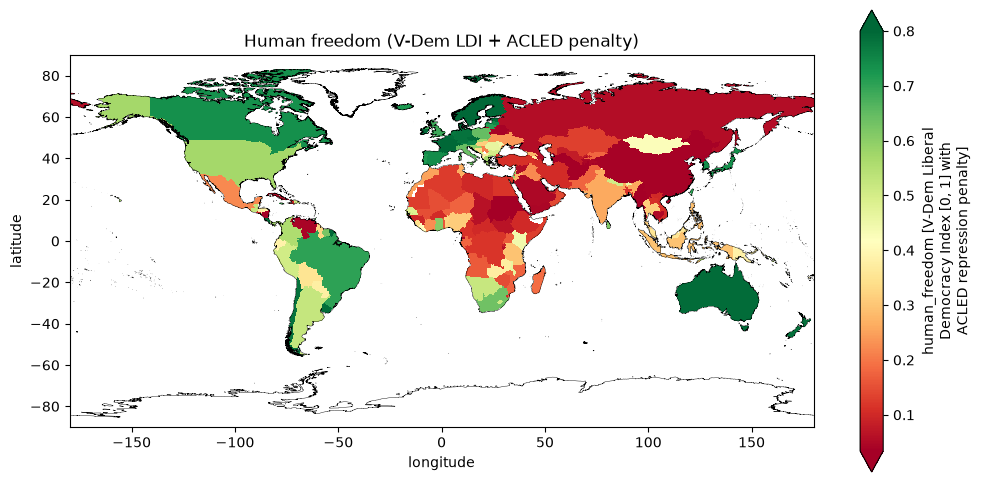

In [ ]:
plot_map(values, cmap='RdYlGn', robust=True, title='Human freedom (V-Dem LDI)')

## 7. Save

In [16]:
out = save_variable(values, VARIABLE)
print(f'wrote {out}')

wrote /Users/lutz/Documents/alfatraining/projects/data-science-notebooks/data/world-livable-atlas/processed/human_freedom.nc
